# PDMS Brushes

# Libraries

In [1]:
%run ../../../setup_workspace.py # ../ means level up 

✓ Workspace ready


In [2]:
import matplotlib
from matplotlib.ticker import ScalarFormatter
from scipy.special import voigt_profile

# Data

In [7]:
Exp_1_2 = BM26_experiment(r"E:\RSF 2025\Vashurkin\Vashurkin_BB_elast_1_2")
Exp_1_4 = BM26_experiment(r"E:\RSF 2025\Vashurkin\Vashurkin_BB_elast_1_4")
Exp_5 = BM26_experiment(r"E:\RSF 2025\Vashurkin\Vashurkin_BB_elast_5")


# Functions

In [5]:
def Voigt_power(x, A, m, sigma, gamma, I_p, p):
    return A * voigt_profile(x - m, sigma, gamma) + I_p * x ** -p

def Voigt(x, A, m, sigma, gamma):
    return A * voigt_profile(x - m, sigma, gamma) 
    
def power(x, I_p, p):
    return I_p * x ** -p

def lin_interp(x, y, i, half):
    return x[i] + (x[i+1] - x[i]) * ((half - y[i]) / (y[i+1] - y[i]))

def half_max_x(x, y):
    half = max(y)/2.0
    signs = np.sign(np.add(y, -half))
    zero_crossings = (signs[0:-2] != signs[1:-1])
    zero_crossings_i = np.where(zero_crossings)[0]
    return [lin_interp(x, y, zero_crossings_i[0], half),
            lin_interp(x, y, zero_crossings_i[1], half)]

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

def log_norm_power(x,I0, q0, s, I_p, p):
    return  log_normal_peak(x, I0, q0, s) + I_p * x ** -p

# Analysis

In [6]:
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial'

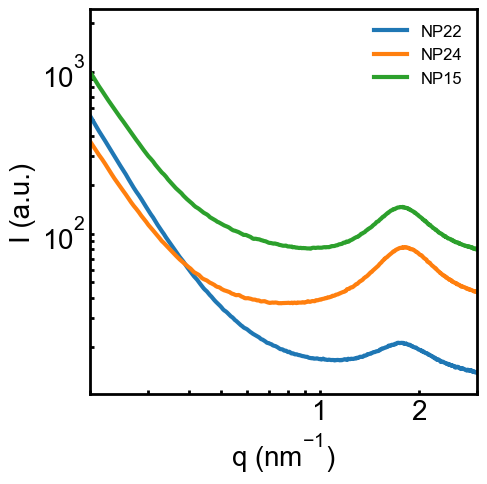

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

Exp = Exp_1_2
q, I = Exp.get_1d_SAXS()
plt.plot(q, I, linewidth=3, label='NP22')


Exp = Exp_1_4
q, I = Exp.get_1d_SAXS()
plt.plot(q, I * 2, linewidth=3, label='NP24')

Exp = Exp_5
q, I = Exp.get_1d_SAXS()
plt.plot(q, I * 4, linewidth=3, label='NP15')


ax.set_xlim(0.2, 3)
#ax.set_ylim(1, 4e3)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.tick_params(axis="both",which='both',direction="in", width=2, length=3)

# Labels - use text instead of math mode
ax.set_xlabel('q (nm$^{-1}$)', fontname='Arial', fontsize=20)
ax.set_ylabel('I (a.u.)', fontname='Arial', fontsize=20)

ax.set_xscale('log')
ax.set_yscale('log')

# Set decimal format for x-axis ticks without trailing zeros
ax.get_xaxis().set_major_formatter(plt.FormatStrFormatter('%g'))

# Set Arial font for tick labels
ax.tick_params(axis='both', which='major', labelsize=20)
for tick in ax.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontname('Arial')
    
plt.legend(frameon=False, fontsize=12)
ax.set_xticks([1, 2])

plt.savefig('SAXS_SC5711.png', dpi=300, bbox_inches='tight', transparent=True)

# 2D plots

In [21]:
poni = r"\\Synology\Data\2025\SC5711\Linkam_SAXS_13keV_AgBe_1p4m.poni"
ai = pyFAI.load(poni)

In [38]:
res = Exp_1_4.integrate2d_SAXS(ai, 2000, unit='q_nm^-1', azim=False)

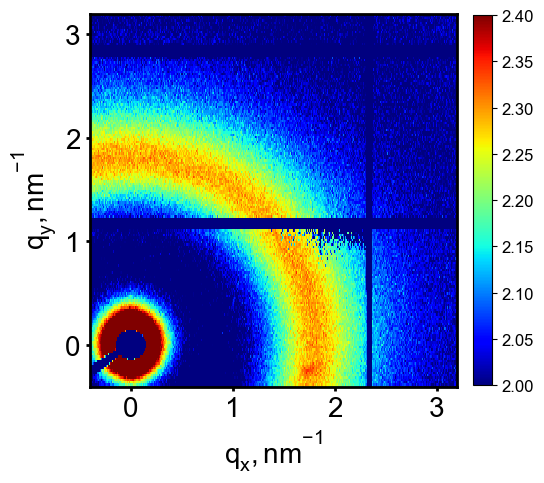

In [58]:
fig, ax1 = plt.subplots(1, 1, figsize=(5.6,5), layout='tight')

cmap = plt.cm.jet

cmap.set_bad(color='black')  # для NaN
cmap.set_over(color='black')  # для значений > vmax
cmap.set_under(color='black') # для значений < vmin

mesh = ax1.pcolormesh(-res[0][1], res[0][2], np.log10(res[0][0]+ 1e-10), vmin=2, vmax=2.4, cmap='jet', rasterized=True)

for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)
    
ax1.set_xlabel('$q_{x},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_ylabel('$q_{y},\\mathrm{nm}^{-1}$', fontsize=20, fontname='Arial', fontweight='bold')
ax1.set_xlim(min( res[0][2]), 3.2)
ax1.set_ylim(min( res[0][2]), 3.2)
cbar = fig.colorbar(mesh, ax=ax1, fraction=0.046, pad=0.04)

ax1.tick_params(axis="both",which='both',direction="out", width=2, length=3)
# Set Arial font for tick labels
ax1.tick_params(axis='both', which='major', labelsize=20)
for tick in ax1.get_xticklabels():
    tick.set_fontname('Arial')
for tick in ax1.get_yticklabels():
    tick.set_fontname('Arial')

    
plt.savefig('Exp1_4_2D.png', dpi=300, bbox_inches='tight', transparent=True)